In [5]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10

In [48]:
# Load city metadata
city_info = pd.read_csv('/home/lpsha/s154446/fractality/data/city_external/city_info.csv')

# Load degree sequences for t50_a10
data_path = '/home/lpsha/s154446/fractality/data/city_degrees/t50_a10/'
city_degrees = {}
for fname in os.listdir(data_path):
    city_name = fname.replace('.npz', '')
    d = np.load(os.path.join(data_path, fname))
    city_degrees[city_name] = d['degree']

# Match cities to metadata
city_info['degrees'] = city_info['city'].map(city_degrees)
city_info = city_info.dropna(subset=['degrees'])

# Create GDP bins
gdp_bins = [0, 5000, 15000, 30000, 50000, 200000]
gdp_labels = ['<5k', '5k-15k', '15k-30k', '30k-50k', '>50k']
city_info['gdp_group'] = pd.cut(city_info['country_gdp_per_capita_usd'], bins=gdp_bins, labels=gdp_labels)

city_info['N_nodes'] = city_info['degrees'].apply(len)
city_info = city_info[city_info['N_nodes'] > 500].copy()

city_info

,city,country,continent,latitude,longitude,population_city_proper,area_km2,population_density_per_km2,founding_era,street_pattern,country_gdp_per_capita_usd,climate_zone,elevation_m,coastal,degrees,gdp_group,N_nodes
2,"Perth, Australia",Australia,Oceania,-31.95,115.86,2085973,6418,325,colonial_19c,grid,51812,Csa,31,yes,"[12, 5, 32, 5, 6, 9, 4, 6, 3, 4, 3, 4, 11, 3, ...",>50k,1949
3,"Santiago, Chile",Chile,South America,-33.45,-70.65,5614000,641,8758,colonial_16c,grid,16265,Csb,520,no,"[85, 100, 102, 11, 13, 3, 3, 5, 4, 4, 63, 5, 5...",15k-30k,3869
4,Monaco,Monaco,Europe,43.74,7.42,39244,2,19622,medieval,organic,190512,Csa,62,yes,"[3, 15, 13, 3, 6, 16, 2, 10, 5, 7, 5, 9, 3, 6,...",>50k,2715
5,"Puerto Vallarta, Mexico",Mexico,North America,20.65,-105.22,291839,121,2412,colonial_16c,organic,10045,Aw,2,yes,"[7, 11, 10, 9, 6, 11, 16, 5, 13, 6, 8, 4, 14, ...",5k-15k,7586
6,"Santa Barbara, California, USA",United States,North America,34.42,-119.70,90911,108,842,colonial_18c,grid,76330,Csb,15,yes,"[4, 3, 6, 24, 3, 4, 3, 15, 4, 14, 2, 4, 7, 4, ...",>50k,6513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,"Bratislava, Slovakia",Slovakia,Europe,48.15,17.11,475503,368,1292,medieval,organic,21088,Cfb,134,no,"[2, 15, 449, 1, 7, 237, 2, 4, 2, 4, 2, 7, 5, 2...",15k-30k,56532
93,"Ljubljana, Slovenia",Slovenia,Europe,46.06,14.51,295504,164,1802,medieval,organic,28439,Cfb,295,no,"[22, 51, 38, 9, 5, 10, 3, 4, 4, 14, 11, 14, 12...",15k-30k,38056
94,"Baku, Azerbaijan",Azerbaijan,Asia,40.41,49.87,2303000,2140,1076,ancient,organic,7723,BSk,-28,yes,"[4, 3, 34, 4, 3, 4, 4, 3, 3, 3, 3, 4, 3, 1, 1,...",5k-15k,85100
95,"Minsk, Belarus",Belarus,Europe,53.90,27.57,2009786,349,5759,medieval,radial,7302,Dfb,220,no,"[36, 8, 3, 15, 4, 6, 9, 6, 5, 4, 2, 4, 2, 4, 4...",5k-15k,126129


In [49]:
def ratio(degrees):
    r = len(degrees[degrees <= 4]) / len(degrees)
    return r

city_info['degree_ratio'] = city_info['degrees'].apply(ratio)

In [92]:
d[d <= 4]

array([4, 2, 1, ..., 0, 1, 1], shape=(173268,))

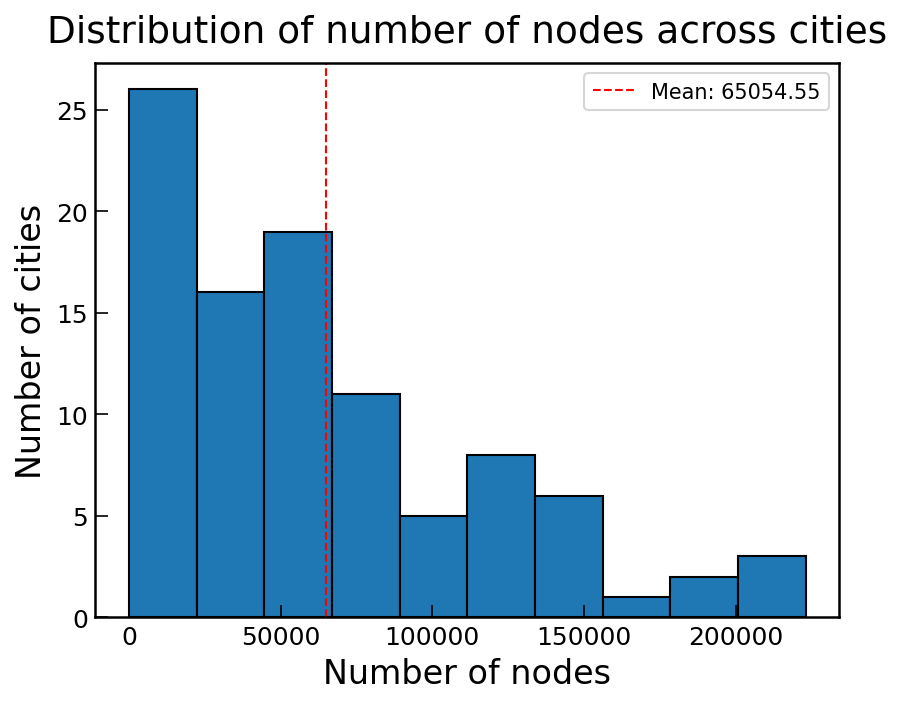

In [36]:
plt.hist(city_info['N_nodes'],bins=10, edgecolor='black')
plt.xlabel('Number of nodes')
m = city_info['N_nodes'].mean()
plt.axvline(m, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {m:.2f}')
plt.legend()
plt.ylabel('Number of cities')
plt.title('Distribution of number of nodes across cities')
plt.show()

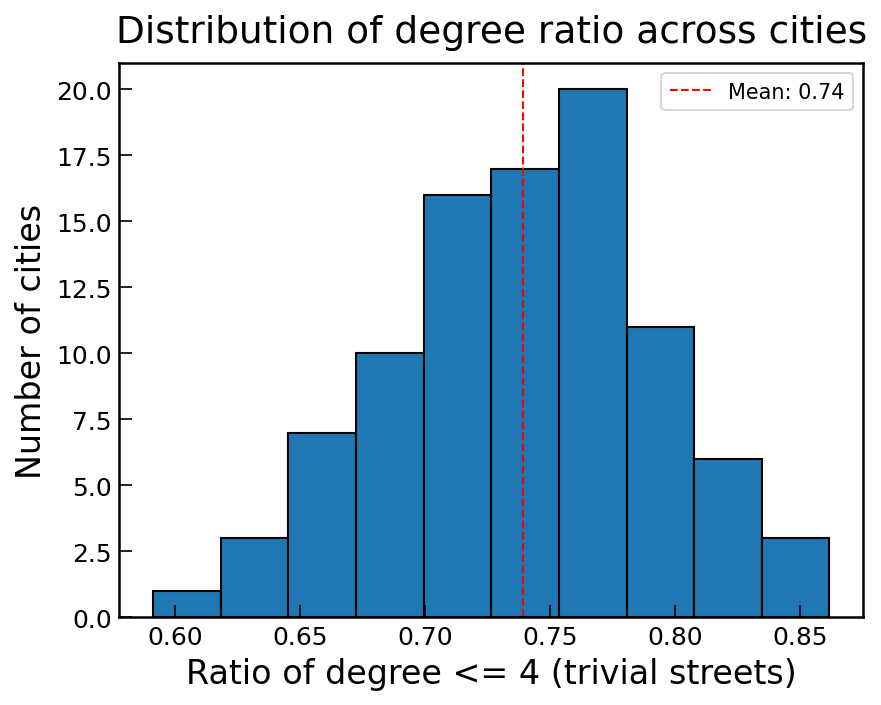

In [93]:
plt.hist(city_info['degree_ratio'],bins=10, edgecolor='black')
plt.xlabel('Ratio of degree <= 4 (trivial streets)')
m = city_info['degree_ratio'].mean()
plt.axvline(m, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {m:.2f}')
plt.legend()
plt.ylabel('Number of cities')
plt.title('Distribution of degree ratio across cities')
plt.show()

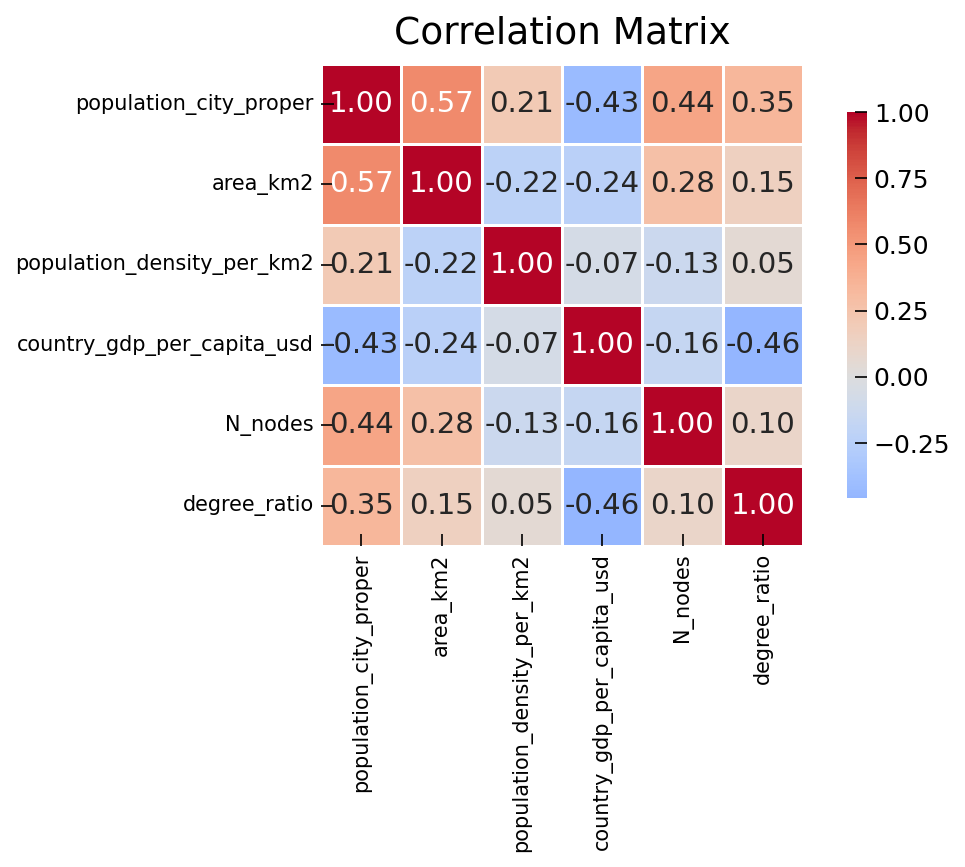

In [52]:
num_cols=['population_city_proper','area_km2','population_density_per_km2','country_gdp_per_capita_usd','N_nodes','degree_ratio']

corr = city_info[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix")

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

Slope: -5.3722, Intercept: 8.2599, R-squared: 0.2991, p-value: 1.1788e-08


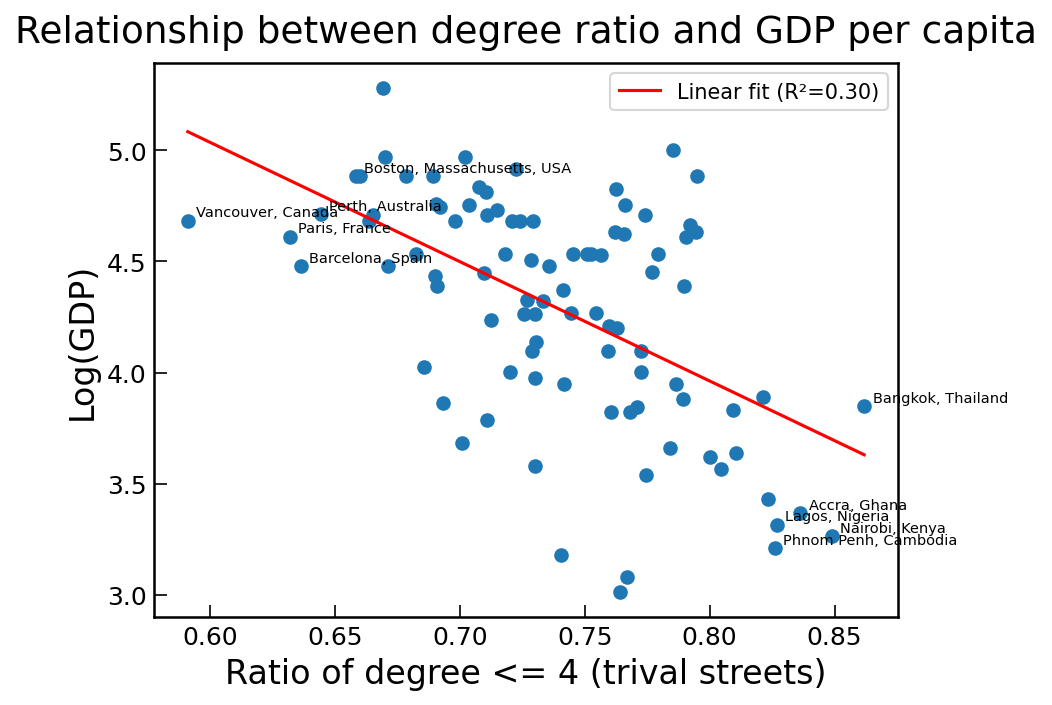

In [53]:
x=city_info['degree_ratio']
y=city_info['country_gdp_per_capita_usd'].apply(lambda gdp: np.log10(gdp) if gdp > 0 else 0)

# linreg
import scipy.stats as stats
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}, R-squared: {r_value**2:.4f}, p-value: {p_value:.4e}")

# plot
xs = np.linspace(x.min(), x.max(), 100)
ys = intercept + slope * xs
plt.plot(xs, ys, color='red', label=f'Linear fit (R²={r_value**2:.2f})')

plt.legend()
plt.xlabel('Ratio of degree <= 4 (trival streets)')
plt.ylabel('Log(GDP)')
plt.title('Relationship between degree ratio and GDP per capita')


for i in range(1, 6):
    row = city_info.loc[city_info['degree_ratio'].nsmallest(i).index[-1]]
    plt.annotate(row["city"], (row["degree_ratio"], 
                               np.log10(row["country_gdp_per_capita_usd"]) if row["country_gdp_per_capita_usd"] > 0 else 0), 
                               fontsize=7,
                               xytext=(4, 2), textcoords="offset points")

for i in range(1, 6):
    row=city_info.loc[city_info['degree_ratio'].nlargest(i).index[-1]]
    plt.annotate(row["city"], (row["degree_ratio"], 
                            np.log10(row["country_gdp_per_capita_usd"]) if row["country_gdp_per_capita_usd"] > 0 else 0), 
                            fontsize=7,
                            xytext=(4, 2), textcoords="offset points")

plt.scatter(x, y)
plt.show()

Slope: 26008465.3474, Intercept: -16257703.3413, R-squared: 0.1191, p-value: 6.5875e-04


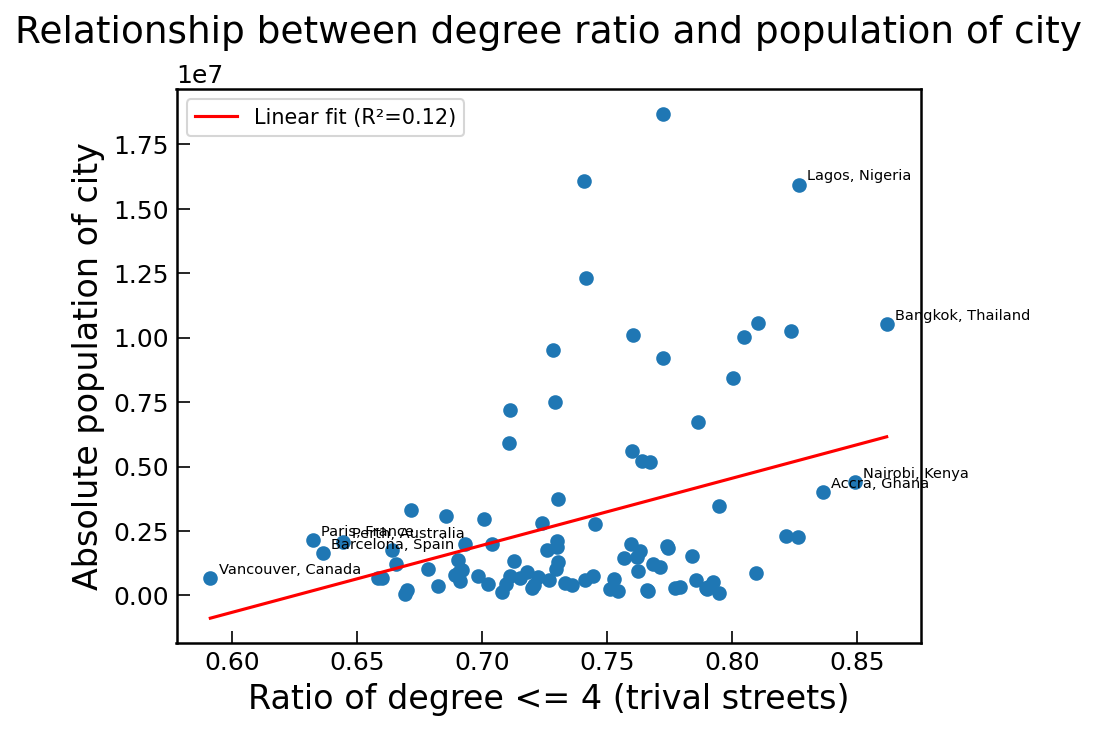

In [94]:
x=city_info['degree_ratio']
y=city_info['population_city_proper']

# linreg
import scipy.stats as stats
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}, R-squared: {r_value**2:.4f}, p-value: {p_value:.4e}")

# plot
xs = np.linspace(x.min(), x.max(), 100)
ys = intercept + slope * xs
plt.plot(xs, ys, color='red', label=f'Linear fit (R²={r_value**2:.2f})')

plt.legend()
plt.xlabel('Ratio of degree <= 4 (trival streets)')
plt.ylabel('Absolute population of city')
plt.title('Relationship between degree ratio and population of city')


for i in range(1, 5):
    row = city_info.loc[city_info['degree_ratio'].nsmallest(i).index[-1]]
    plt.annotate(row["city"], (row["degree_ratio"], row["population_city_proper"]), fontsize=7,
                               xytext=(4, 2), textcoords="offset points")

for i in range(1, 5):
    row=city_info.loc[city_info['degree_ratio'].nlargest(i).index[-1]]
    plt.annotate(row["city"], (row["degree_ratio"], row["population_city_proper"]), fontsize=7,
                            xytext=(4, 2), textcoords="offset points")

plt.scatter(x, y)
plt.show()

In [100]:
print(len(d[d <= 4]))
print(len(d[d > 4]))

173268
27779


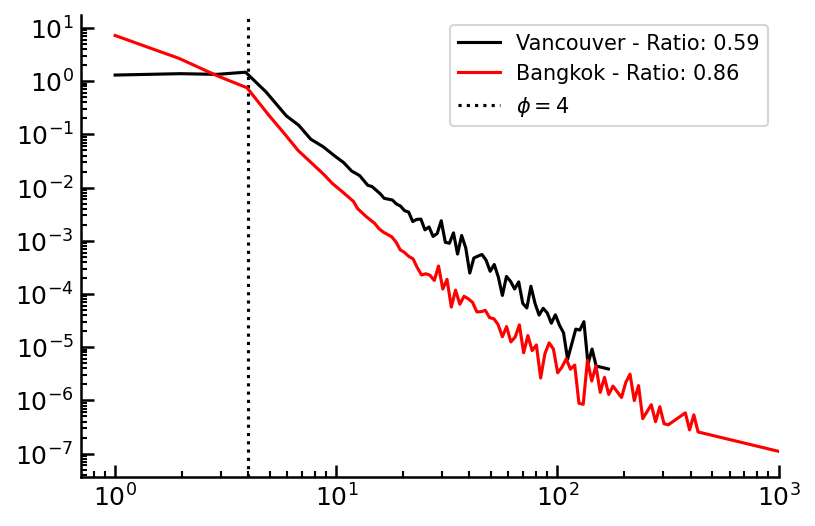

In [91]:
fig, ax = plt.subplots(figsize=(6, 4))

van=city_info[city_info.city == 'Vancouver, Canada']
d=np.array(van.degrees)[0]
y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='k',label='Vancouver - Ratio: '+str(np.round(van.degree_ratio.values[0],2)))

ban=city_info[city_info.city == 'Bangkok, Thailand']
d=np.array(ban.degrees)[0]
y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='r',label='Bangkok - Ratio: '+str(np.round(ban.degree_ratio.values[0],2)))

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.yaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=1.0)
plt.xscale('log')
plt.yscale('log')
ax.set_xlim(right=1000)


ax.axvline(4, color='k', linestyle='dotted', label=r'$\phi = $' + str(4),zorder=-1)
plt.legend()
plt.show()

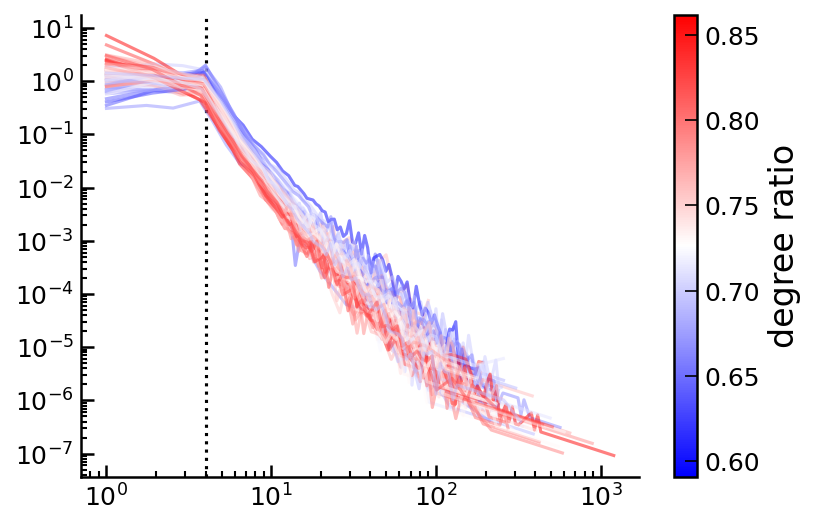

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(6, 4))

# Set up colormap based on degree_ratio range
norm = Normalize(vmin=city_info['degree_ratio'].min(),
                 vmax=city_info['degree_ratio'].max())
cmap = plt.cm.bwr  # pick any: viridis, plasma, coolwarm, etc.

for row, city in city_info.iterrows():
    ratio = city.degree_ratio
    dd = city.degrees
    d = np.array(dd)
    y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True)
    x = x[:-1]
    x_nn = x[y != 0][:-1]
    y_nn = y[y != 0][:-1]
    ax.plot(x_nn, y_nn, alpha=0.5, zorder=2, color=cmap(norm(ratio)))

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.yaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=1.0)
plt.xscale('log')
plt.yscale('log')
# ax.set_xlim(right=1000)

ax.axvline(4, color='k', linestyle='dotted', label=r'$\phi = $' + str(4), zorder=-1)

# Add colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('degree ratio')

plt.show()

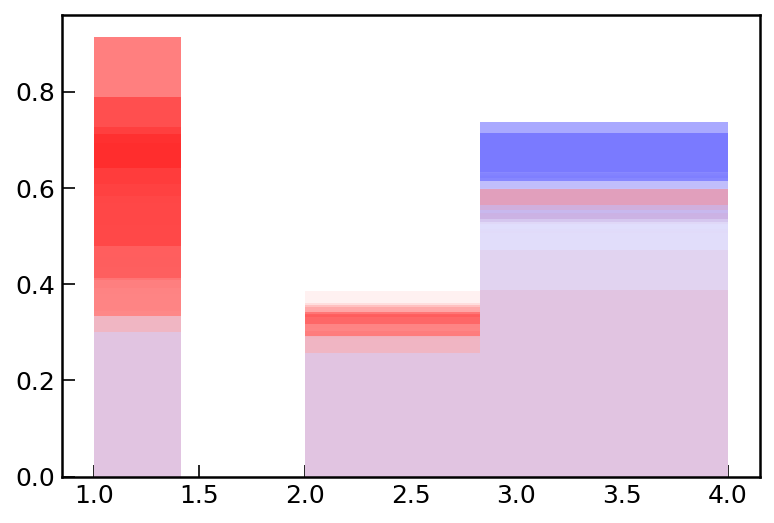

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

# Set up colormap based on degree_ratio range
norm = Normalize(vmin=city_info['degree_ratio'].min(),
                 vmax=city_info['degree_ratio'].max())
cmap = plt.cm.bwr  # pick any: viridis, plasma, coolwarm, etc.

for row, city in city_info.iterrows():
    ratio = city.degree_ratio
    dd = city.degrees
    # dd smaller than 4
    d = np.array(dd)
    d = d[d <= 4]


plt.show()